In [4]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
# from netCDF4 import Dataset
import sys

import cartopy.feature as cfeature
from matplotlib import cm

import cftime
import cmocean

# Check the created cell mask and edge mask

In [2]:
# Define the empty dictionaries
fpath_tgrid = {}
fpath_ckdtree = {}

# info for the grids
gname_oce = 'r2b9_oce_r0004'
gname_atm = 'r2b8_atm_r0033'
lev_oce = 'L72'

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b8_atm_r0033_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b9_oce_r0004_res0.30_180W-180E_90S-90N.nc')

In [3]:
# tgrid info
tgrid = xr.open_dataset(fpath_tgrid["oce"])
# mask
mask_pc_middle = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_middle_sections_masks_oce_r2b9.nc")
# sections
sections = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/all_sections_r2b9_NilsVersion.nc")

In [4]:
north = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_middle_sections_NorthBoundarySection_oce_r2b9.nc")
west = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_middle_sections_WestBoundarySection_oce_r2b9.nc")
east = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_middle_sections_EastBoundarySection_oce_r2b9.nc")
south = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_middle_sections_SouthBoundarySection_oce_r2b9.nc")

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


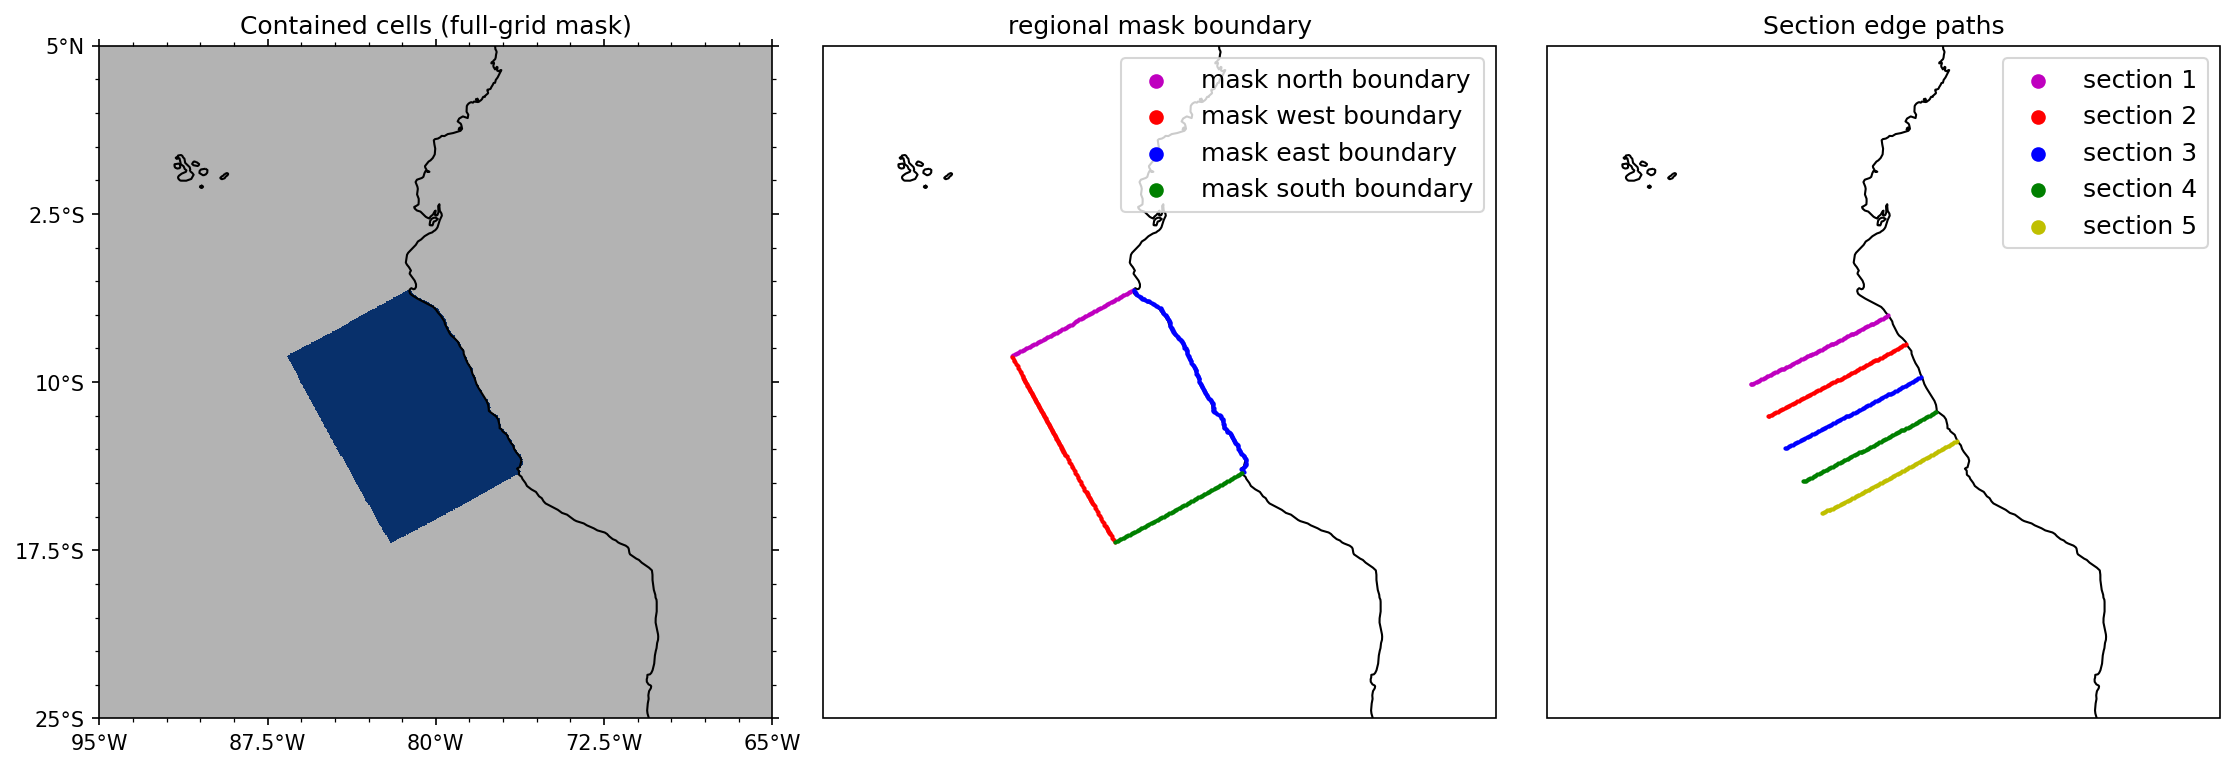

In [7]:
zeros = xr.zeros_like(tgrid["cell_area"], dtype="float64")
zeros.loc[dict(cell=mask_pc_all["contained_cells"])] = 1.0

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    dpi=150,
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# ---- Left panel: full-grid cell mask via pyic ----
ax0, hm0 = zeros.pyic.plot(
    ax=axes[0],
    cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    plot_method="tgrid",
    cmap="Blues",
    land_facecolor="none",
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    clim=[0, 1],
)
axes[0].set_title("Contained cells (full-grid mask)")

# ---- Right panel: section edges as scatter ----
ax = axes[1]
ax.set_xlim(-95, -65)
ax.set_ylim(-25, 5)
ax.set_aspect("equal", adjustable="box")
ax.coastlines()
ax.grid(False)

ax.scatter(
    north.elon.compute(),
    north.elat.compute(),
    c="m", s=1, zorder=3, label="mask north boundary"
)

ax.scatter(
    west.elon.compute(),
    west.elat.compute(),
    c="r", s=1, zorder=3, label="mask west boundary"
)

ax.scatter(
    east.elon.compute(),
    east.elat.compute(),
    c="b", s=1, zorder=3, label="mask east boundary"
)

ax.scatter(
    south.elon.compute(),
    south.elat.compute(),
    c="g", s=1, zorder=3, label="mask south boundary"
)

ax.set_title("regional mask boundary")
ax.legend(markerscale=6, fontsize=12)

# ---- Right panel: section edges as scatter ----
ax = axes[2]
ax.set_xlim(-95, -65)
ax.set_ylim(-25, 5)
ax.set_aspect("equal", adjustable="box")
ax.coastlines()
ax.grid(False)

# NOTE: elon / elat are usually in radians → convert if needed
elon = sections.elon
elat = sections.elat

ax.scatter(
    elon[sections.mask_section1 != 0],
    elat[sections.mask_section1 != 0],
    c="m", s=1, zorder=3, label="section 1"
)
ax.scatter(
    elon[sections.mask_section2 != 0],
    elat[sections.mask_section2 != 0],
    c="r", s=1, zorder=3, label="section 2"
)
ax.scatter(
    elon[sections.mask_section3 != 0],
    elat[sections.mask_section3 != 0],
    c="b", s=1, zorder=3, label="section 3"
)
ax.scatter(
    elon[sections.mask_section4 != 0],
    elat[sections.mask_section4 != 0],
    c="g", s=1, zorder=3, label="section 4"
)
ax.scatter(
    elon[sections.mask_section5 != 0],
    elat[sections.mask_section5 != 0],
    c="y", s=1, zorder=3, label="section 5"
)

ax.set_title("Section edge paths")
ax.legend(markerscale=6, fontsize=12)

plt.tight_layout()
plt.show()


# Create the tgrid focus on the selected region
- using the mask to generate the specific tgrid file for the selected cells

## Function: crop tgrid according to mask

In [5]:
def crop_tgrid_to_region(tgrid, mask):
    """Crop tgrid to the region defined by the mask.

    Parameters
    ----------
    tgrid : xarray.Dataset
        The tgrid dataset.
    mask : xarray.DataArray
        The mask defining the region to crop to.

    Returns
    -------
    xarray.Dataset
        The cropped tgrid dataset.
    """
    ireg_c = mask["contained_cells"].astype(int)
    crop_tg = pyic.xr_crop_tgrid(tgrid, ireg_c)
    return crop_tg

## r2b9

In [ ]:
# Define the empty dictionaries
fpath_tgrid = {}
fpath_ckdtree = {}

# info for the grids
gname_oce = 'r2b9_oce_r0004'
gname_atm = 'r2b8_atm_r0033'
lev_oce = 'L72'

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b8_atm_r0033_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b9_oce_r0004_res0.30_180W-180E_90S-90N.nc')

In [ ]:
# tgrid info
tgrid = xr.open_dataset(fpath_tgrid["oce"])

# mask
mask_pc_middle = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_middle_sections_masks_oce_r2b9.nc")

# crop tgrid
print("cropping the tgrid:")
crop_tg = crop_tgrid_to_region(tgrid, mask_pc_middle)

# Convert cropped tgrid to ICON-ready datasets
ds_IcD = pyic.convert_tgrid_data(crop_tg)
print("cropped tgrid has been created.")

# Optional: keep selected ncells index (still 0-based)
ncells_selected = crop_tg.cell.rename({"cell": "ncells"})

In [24]:
outpath = "/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/"
crop_tg.to_netcdf(f"{outpath}pc_middle_mask_cropped_tgrid_oce_r2b9.nc")

cropped tgrid has been created.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f5ee03b3390>])

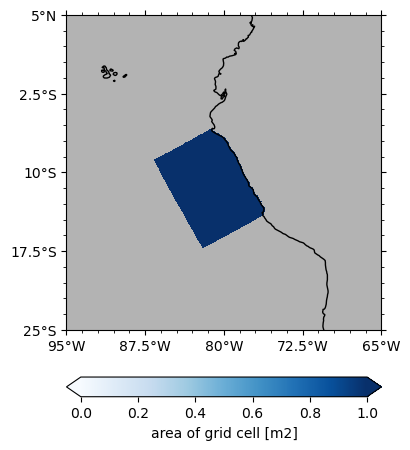

In [28]:
# test the crop_tg
crop_tg_test = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_middle_mask_cropped_tgrid_oce_r2b9.nc")
# transfer to ICON readable dataset
ds_IcD = pyic.convert_tgrid_data(crop_tg_test)
print("cropped tgrid has been created.")
# Optional: keep selected ncells index (still 0-based)
ncells_selected = crop_tg_test.cell.rename({"cell": "ncells"})

zeros = xr.zeros_like(tgrid["cell_area"], dtype="float64")
zeros.loc[dict(cell=ncells_selected.rename({"ncells": "cell"}))] = 1.0

# check the mask 
zeros.pyic.plot(
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    plot_method="tgrid",
    cmap="Blues",
    land_facecolor="none",
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    clim=[0, 1],
)


### bathymetry

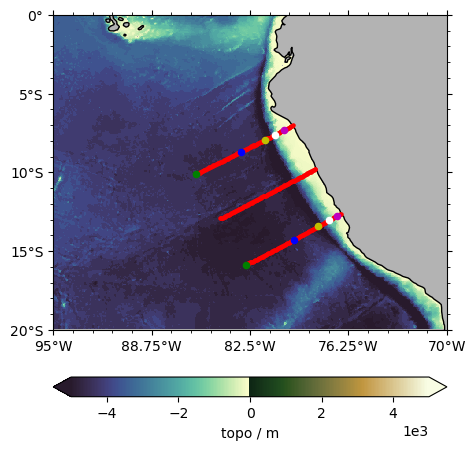

In [16]:
fx_path = "/pool/data/ICON/oes/input/r0005/OceanOnly_IcosSymmetric_4932m_rotatedZ37d_modified_srtm30_1min/L72/R2B9L72_fx.nc"
ds_fx = xr.open_dataset(fx_path)

ax_main, _ = (-ds_fx.column_thick_c).pyic.plot(lon_reg=[-95, -70], lat_reg=[ -20, 0], cmap=cmocean.cm.topo, clim=[-5000,5000], grid_type='native', res=0.05, cbar_str='topo / m')

elon = sections.elon
elat = sections.elat
ax_main.scatter(
    elon[sections.mask_section1 != 0],
    elat[sections.mask_section1 != 0],
    c="r", s=5, zorder=3, label="section 1"
)

ax_main.scatter(
    elon[sections.mask_section3 != 0],
    elat[sections.mask_section3 != 0],
    c="r", s=5, zorder=3, label="section 3"
)

ax_main.scatter(
    elon[sections.mask_section5 != 0],
    elat[sections.mask_section5 != 0],
    c="r", s=5, zorder=3, label="section 5"
)

ax_main.scatter(-81.554, -7.939, c='y', s=20, zorder=3, label="CCS1_1")
ax_main.scatter(-78.178, -13.431, c='y', s=20, zorder=3, label="CCS1_2")

ax_main.scatter(-80.899, -7.606, c='w', s=20, zorder=3, label="CCS2_1")
ax_main.scatter(-77.506, -13.057, c='w', s=20, zorder=3, label="CCS2_2")

ax_main.scatter(-80.331, -7.325, c='m', s=20, zorder=3, label="CCS3_1")
ax_main.scatter(-76.956, -12.754, c='m', s=20, zorder=3, label="CCS3_2")

ax_main.scatter(-83.062, -8.698, c='b', s=20, zorder=3, label="CCS4_1")
ax_main.scatter(-79.704, -14.284, c='b', s=20, zorder=3, label="CCS4_2")

ax_main.scatter(-85.95389020750532, -10.12060537018413, c='g', s=20, zorder=3, label="CCS4_1")
ax_main.scatter(-82.78540916611692, -15.889067595180334, c='g', s=20, zorder=3, label="CCS4_2")

plt.show()

## r2b7

In [ ]:
# Define the empty dictionaries
fpath_tgrid = {}
fpath_ckdtree = {}

# info for the grids
gname_oce = 'r2b7_oce_r0005'
gname_atm = 'r2b5_atm_r0030'
lev_oce = 'L72'

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b8_atm_r0033_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b9_oce_r0004_res0.30_180W-180E_90S-90N.nc')

In [13]:
# tgrid info
tgrid = xr.open_dataset(fpath_tgrid["oce"])
# masks
mask_pc_all = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_all_sections_masks_oce_r2b7.nc")
mask_pc_middle = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_middle_sections_masks_oce_r2b7.nc")
mask_pc_north = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_north_sections_masks_oce_r2b7.nc")
mask_pc_south = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_south_sections_masks_oce_r2b7.nc")

# crop the corresponding tgrid file
print("cropping the tgrid:")
crop_tg_pc_all = crop_tgrid_to_region(tgrid, mask_pc_all)
crop_tg_pc_middle = crop_tgrid_to_region(tgrid, mask_pc_middle)
crop_tg_pc_north = crop_tgrid_to_region(tgrid, mask_pc_north)
crop_tg_pc_south = crop_tgrid_to_region(tgrid, mask_pc_south)

cropping the tgrid:
find edges
cut coordinates
reindex
find edges
cut coordinates
reindex
find edges
cut coordinates
reindex
find edges
cut coordinates
reindex


In [14]:
outpath = "/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/"
crop_tg_pc_all.to_netcdf(f"{outpath}pc_all_mask_cropped_tgrid_oce_r2b7.nc")
crop_tg_pc_middle.to_netcdf(f"{outpath}pc_middle_mask_cropped_tgrid_oce_r2b7.nc")
crop_tg_pc_north.to_netcdf(f"{outpath}pc_north_mask_cropped_tgrid_oce_r2b7.nc")
crop_tg_pc_south.to_netcdf(f"{outpath}pc_south_mask_cropped_tgrid_oce_r2b7.nc")

# Test `funcs_crop_section.py`
- test if the `center_to_section_edges_new` is suitable for my own workflow
    - workflow:
        - select the target points
        - calculation
        - interpolates center to section edge
        - add distance coordinate


In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline
import pyicon as pyic
import pandas as pd
import gsw

import intake
from distributed import Client, LocalCluster
import funcs_crop_section as functions

In [2]:
cluster = LocalCluster(
    n_workers=32, 
    threads_per_worker=1,
    local_directory="/scratch/m/m301254/dask_tmp/"
)
client = Client(cluster)
client.restart()   
client

2026-02-01 16:05:24,460 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,486 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,519 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,521 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,533 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,555 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,579 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,581 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,589 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,592 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,597 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,604 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,609 - distributed.nanny - WARNING - Restarting worker
2026-02-01 16:05:24,614 - distributed.

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 32,Total memory: 251.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46589,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42389,Total threads: 1
Dashboard: http://127.0.0.1:34805/status,Memory: 7.86 GiB
Nanny: tcp://127.0.0.1:40565,


In [3]:
eerie_cat=intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
model_list=list(eerie_cat['dkrz.disk.model-output'])
model = 'icon-esm-er'
expid=list(eerie_cat['dkrz.disk.model-output'][model])

# historical run: 1950-2014
model, expid, version, realm, gridspec = 'icon-esm-er','hist-1950','v20240618','ocean','native'
cat = eerie_cat['dkrz.disk.model-output'][model][expid][version][realm][gridspec]
ocn_H_m = cat['model-level_monthly_mean'].to_dask()   # contains u/v, depth（monthly）

# ssp234 run: 2015-2050
model, expid, version, realm, gridspec = 'icon-esm-er','highres-future-ssp245','v20240618','ocean','native'
cat = eerie_cat['dkrz.disk.model-output'][model][expid][version][realm][gridspec]
ocn_S_m = cat['model-level_monthly_mean'].to_dask()   # contains u/v, depth（monthly）

# tgrid and fx data
tgrid_path = "/pool/data/ICON/oes/input/r0005/OceanOnly_IcosSymmetric_4932m_rotatedZ37d_modified_srtm30_1min/OceanOnly_IcosSymmetric_4932m_rotatedZ37d_modified_srtm30_1min.nc"
fx_path = "/pool/data/ICON/oes/input/r0005/OceanOnly_IcosSymmetric_4932m_rotatedZ37d_modified_srtm30_1min/L72/R2B9L72_fx.nc"
ds_tgrid = xr.open_dataset(tgrid_path)
ds_fx = xr.open_dataset(fx_path)

# level info
z72 = xr.open_dataset(fx_path)["depth"].values.astype(float)   # (72,) meters
k300 = int(np.where(z72 <= 300)[0].max() + 1)  # level closest to 300 m

In [4]:
# read sections file
sections = xr.open_dataset("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/all_sections_r2b9_NilsVersion.nc")

# build ICON section grids
ds_IcD_s1, adj_cells_s1, crop_tg_s1 = functions.build_section_IcD(ds_tgrid, sections, "mask_section1")

find edges
cut coordinates
reindex


## Functions: full workflow
- select the target points
- calculations
- interpolates center to section edge
- add distance coordinate


In [19]:
def xr_scalar_cell2edges_par_new(ds_IcD, scalar, var_name):
    """
    Map scalar from cell centers to edges safely, bypassing xarray alignment issues.
    Works even if there are duplicate edges.
    """
    ic0 = ds_IcD.adjacent_cell_of_edge.isel(nc_e=0).values
    ic1 = ds_IcD.adjacent_cell_of_edge.isel(nc_e=1).values
    d0 = ds_IcD.edge_cell_distance.isel(nc_e=0).values
    d1 = ds_IcD.edge_cell_distance.isel(nc_e=1).values

    scalar_arr = scalar.values
    if scalar_arr.ndim == 3:
        val0 = scalar_arr[:, :, ic0] * d0[None, None, :]
        val1 = scalar_arr[:, :, ic1] * d1[None, None, :]
        edge_vals = (val0 + val1) / (d0 + d1)[None, None, :]
        dims = ["time", "depth", "edge"]
        coords = {"time": scalar.time, "depth": scalar.depth}
    elif scalar_arr.ndim == 2:
        val0 = scalar_arr[:, ic0] * d0[None, :]
        val1 = scalar_arr[:, ic1] * d1[None, :]
        edge_vals = (val0 + val1) / (d0 + d1)[None, :]
        dims = ["depth", "edge"]
        coords = {"depth": scalar.depth}
    else:
        raise ValueError("Unsupported da shape")

    # now assign edge coordinates correctly from the dataset
    coords["elon"] = ("edge", ds_IcD["elon"].values)
    coords["elat"] = ("edge", ds_IcD["elat"].values)

    da_edge = xr.DataArray(edge_vals, 
                           dims=dims, 
                           coords=coords, 
                           name=scalar.name if scalar.name is not None else var_name)
    return da_edge

def center_to_section_edges_new(
    ds_IcD,
    ds,
    ds_tgrid,
    muxin_sec,
    crop_tg,
    section_name,
    var_name
):
    """
    Computes interpolated scalar from cell to edges. 
    ds need to be pre-selected by section (e.g., ds = ds_raw.sel(ncells=adj_cells))

    Returns
    -------
    da_e : xarray.DataArray
        da on section edges
    """

    # interpolate da from cells to edges
    da_e = xr_scalar_cell2edges_par_new(
        ds_IcD,
        ds.rename({'ncells': 'cell'}),
        var_name
    )

    # original section edge indices
    sec_ind = ds_tgrid.edge_index.where(
        muxin_sec[section_name] != 0,
        drop=True
    ).values

    # attach edge_index from cropped grid
    da_e = da_e.assign_coords(edge_index=crop_tg.edge_index)

    # keep only section edges
    mask = np.isin(da_e.edge_index, sec_ind)
    da_e = da_e.sel(edge=mask)

    return da_e

In [21]:
# select the section
def select_section_TS(ds, wet_c, adj_cells, t0, t1, depth, var_name="to"):
    """
    pre-select the adjacent points along the defined section (edge)
    and clean the data to make topography (bathymetry) = NaN.
    """
    var = ds[var_name].sel(time=slice(t0, t1), ncells=adj_cells).isel(depth=slice(0,depth))
    wet = wet_c.sel(ncells=adj_cells).isel(depth=slice(0,depth)) # oce points == 1.0

    # clean the data; bathymetry=NaN
    var = var.where(wet > 0).load()  # as .compute()

    # load to DataArray
    da = xr.DataArray(
        var,
        dims=("time", "depth", "ncells"),
        coords={"time": var.time, "depth": var.depth, "ncells": var.ncells},
        name=var_name
    )
    return da

# calculation: trend
def trend_per_decade(da):
    """
    Linear trend per decade.
    da: DataArray(time, depth, cell)
    """
    t = da["time"].dt.year + (da["time"].dt.dayofyear - 1) / 365.25
    t = t.astype("float64")
    t0 = t - t.mean("time")
    y0 = da - da.mean("time")

    slope = (t0 * y0).sum("time") / (t0**2).sum("time")
    return slope * 10.0


# interpolates center variable (trend) to section edge
def section_trend(da_trend, sections, ds_IcD, crop_tg, section_name, var_name):
    """
    interpolate the cell center data to cell edge
    using imported functions.center_to_section_edges_new
    """
    tr_e = center_to_section_edges_new(
        ds_IcD = ds_IcD,
        ds = da_trend,
        ds_tgrid = ds_tgrid,
        muxin_sec = sections,
        crop_tg = crop_tg,
        section_name = section_name,
        var_name=var_name,
    )
    
    tr_e = functions.add_section_distance(tr_e)
    return tr_e

In [7]:
# select
da_to_H_s1 = select_section_TS(ocn_H_m, ds_fx["wet_c"], adj_cells_s1, "1980-01-01", "2010-12-31", k300, var_name="to")

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [8]:
# calculate trend
T_to_H_s1 = trend_per_decade(da_to_H_s1)

In [22]:
T1_H = section_trend(T_to_H_s1, sections, ds_IcD_s1, crop_tg_s1, "mask_section1", "to")

In [23]:
T1_H

<xarray.DataArray 'to' (depth: 29, edge: 124)> Size: 29kB
array([[-0.06613304, -0.13607747, -0.13152718, ..., -0.07703839,
        -0.07705303, -0.0770379 ],
       [-0.06475393, -0.12887592, -0.12917227, ..., -0.07501587,
        -0.07510355, -0.07501002],
       [-0.06834658, -0.1396307 , -0.13760374, ..., -0.07223338,
        -0.07235021, -0.07204035],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.01721677,
         0.01742239,  0.01750152],
       [ 0.        ,  0.        ,  0.        , ...,  0.02061626,
         0.02090082,  0.02103854],
       [ 0.        ,  0.        ,  0.        , ...,  0.02439743,
         0.02474356,  0.02495058]], shape=(29, 124))
Coordinates:
  * depth       (depth) float64 232B 1.0 3.1 5.45 8.1 ... 246.4 271.8 299.5
    elon        (edge) float64 992B -1.393 -1.393 -1.394 ... -1.499 -1.499 -1.5
    elat        (edge) float64 992B -0.1225 -0.123 -0.1235 ... -0.1762 -0.1761
    edge_index  (edge) int32 496B 12513133 12513135 ... 12372930 12372929
    distance    (edge) float64 992B 0.0 6.495 12.99 19.48 ... 755.5 759.3 763.1
Dimensions without coordinates: edge

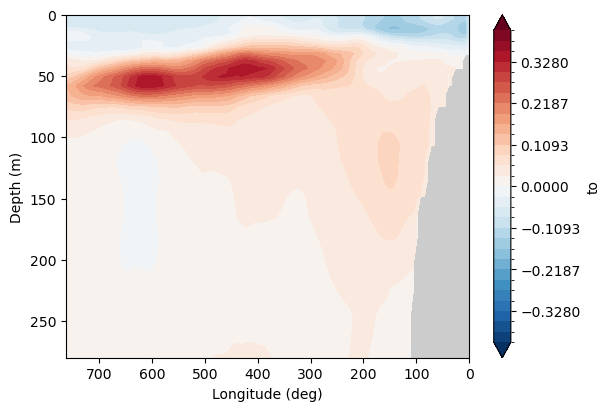

In [33]:

vmin2 = -0.41
vmax2 = 0.41

fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)

cmap = plt.get_cmap("RdBu_r").copy()

cf = T1_H.where(T1_H != 0.0).plot.contourf(
        ax=ax, x="distance", y="depth",
        levels=31, cmap=cmap,
        add_colorbar=True,
        vmin=vmin2, vmax=vmax2, extend="both"
)
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_ylim(280, 0)
# ax.set_title(title)
ax.set_xlabel("Longitude (deg)")
ax.set_ylabel("Depth (m)")
ax.set_facecolor("0.8")

cbar = fig.colorbar(cf, ax=axes, orientation="vertical", shrink=0.9, pad=0.02)
ticks = np.arange(-0.4, 0.401, 0.1)
cbar.set_ticks(ticks)
cbar.set_ticklabels(["0" if np.isclose(t, 0) else f"{t:.1f}" for t in ticks])

cbar.set_label("Temperature trend (°C per decade)")
plt.show()

# Test: new output in `mux0003_b5b7`

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
import sys
import cartopy.feature as cfeature
from matplotlib import cm
import cftime

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.


ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


In [2]:
# data, grid paths
run_def='mux0001_b5b7'

gname_oce = 'r2b7_oce_r0005'
gname_atm = 'r2b5_atm_r0030'
lev_oce = 'L72'

# data paths
path_data = {}
path_data["def"] = (f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_def}/outdata/')

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# ckdtree paths
fpath_tgrid = {}
fpath_ckdtree = {}
# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc')

# tgrid files
ds_tg = {}
ds_tg["atm"] = xr.open_dataset(fpath_tgrid['atm'])
ds_tg["oce"] = xr.open_dataset(fpath_tgrid['oce'])

In [37]:
# regional mask and its cropped files
mask_atm = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/pc_masks_atm_full-dim.nc")

In [4]:
atm2d = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_atm_2d_13300101T000000Z.nc")

/tmp/ipykernel_1416246/2052240664.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  atm2d = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_atm_2d_13300101T000000Z.nc")


In [5]:
atm2d

<xarray.Dataset> Size: 733MB
Dimensions:        (ncells: 81920, vertices: 3, time: 60, height: 1, height_2: 1)
Coordinates:
  * time           (time) object 480B 1330-02-01 00:00:00 ... 1335-01-01 00:0...
  * height         (height) float64 8B 10.0
  * height_2       (height_2) float64 8B 2.0
    clon           (ncells) float64 655kB ...
    clat           (ncells) float64 655kB ...
Dimensions without coordinates: ncells, vertices
Data variables: (12/40)
    clon_bnds      (ncells, vertices) float64 2MB ...
    clat_bnds      (ncells, vertices) float64 2MB ...
    pres_msl       (time, ncells) float32 20MB ...
    pres_sfc       (time, ncells) float32 20MB ...
    t_s            (time, ncells) float32 20MB ...
    clct           (time, ncells) float32 20MB ...
    ...             ...
    t_ice          (time, ncells) float32 20MB ...
    h_ice          (time, ncells) float32 20MB ...
    albvisdif      (time, ncells) float32 20MB ...
    albvisdir      (time, ncells) float32 20MB ...
    albnirdif      (time, ncells) float32 20MB ...
    albnirdir      (time, ncells) float32 20MB ...
Attributes:
    CDI:                  Climate Data Interface version 2.2.4 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  30
    grid_file_uri:        http://icon-downloads.mpimet.mpg.de/grids/public/ic...
    uuidOfHGrid:          a668eac0-fe2e-11e4-9a47-e3e5371a87a7
    source:               version: 2025.04; revision: icon-2025.04-223-g3f064...
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    history:              Sun Mar 01 03:54:33 2026: cdo -r -O -z zstd clone /...
    references:           see MPIM/DWD publications
    comment:              Muxin Hu (m301254) on l30695 (Linux 4.18.0-553.104....
    CDO:                  Climate Data Operators version 2.2.2 (https://mpime...

In [35]:
atm3d = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_atm_3d_13300101T000000Z.nc")["u"]

/tmp/ipykernel_731798/1373374858.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  atm3d = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_atm_3d_13300101T000000Z.nc")["u"]


Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7ffb41e00910>])

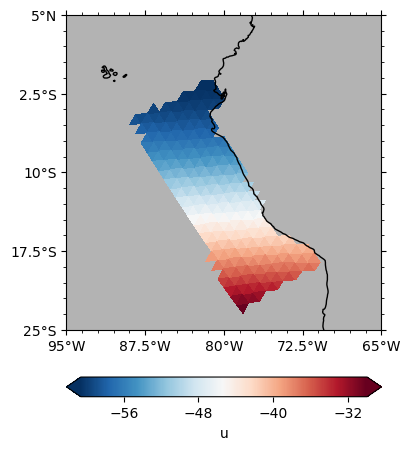

In [38]:
masked_ave = atm3d.isel(height=0).where(mask_atm["pc_all"] == 1.0).mean(dim="time")
masked_ave.pyic.plot(
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    plot_method="tgrid",
    cmap="RdBu_r",
    land_facecolor="none",
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    # clim=[0, 1],
)

In [3]:
mask_oce = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/full_masks_pc_all_oce_r2b7.nc")

In [22]:
oce_flx = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_oce_flx_13300101T000000Z.nc")

/tmp/ipykernel_1416246/1400530601.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  oce_flx = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_oce_flx_13300101T000000Z.nc")


In [ ]:
oce_tke = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_oce_tke_13300101T000000Z.nc")["tke_Tsot"]
oce_tke

/tmp/ipykernel_731798/1699096819.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  oce_tke = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_oce_tke_13300101T000000Z.nc")["tke_Ttot"]


<xarray.DataArray 'tke_Ttot' (time: 60, depth: 73, ncells: 935760)> Size: 16GB
[4098628800 values with dtype=float32]
Coordinates:
  * time     (time) object 480B 1330-02-01 00:00:00 ... 1335-01-01 00:00:00
  * depth    (depth) float64 584B 0.0 2.0 4.2 ... 5.412e+03 5.681e+03 5.951e+03
    clon     (ncells) float64 7MB ...
    clat     (ncells) float64 7MB ...
Dimensions without coordinates: ncells
Attributes:
    standard_name:                tke_Ttot
    long_name:                    TKE tend tot
    units:                        m2 s-3
    code:                         255
    CDI_grid_type:                unstructured
    number_of_grid_in_reference:  1

In [50]:
oce_bgt = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_oce_bgt_13300101T000000Z.nc")["Tt_srf"]
oce_bgt

/tmp/ipykernel_731798/3773855881.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  oce_bgt = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0003_b5b7/outdata/mux0003_b5b7_oce_bgt_13300101T000000Z.nc")["Tt_srf"]


<xarray.DataArray 'Tt_srf' (time: 60, depth: 72, ncells: 935760)> Size: 16GB
[4042483200 values with dtype=float32]
Coordinates:
  * time     (time) object 480B 1330-02-01 00:00:00 ... 1335-01-01 00:00:00
  * depth    (depth) float64 576B 1.0 3.1 5.45 ... 5.279e+03 5.546e+03 5.816e+03
    clon     (ncells) float64 7MB ...
    clat     (ncells) float64 7MB ...
Dimensions without coordinates: ncells
Attributes:
    standard_name:                Tt_srf
    long_name:                    temp. tend. surface refractor
    units:                        K s-1 m
    code:                         255
    CDI_grid_type:                unstructured
    number_of_grid_in_reference:  1

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7ffb58a8c3d0>])

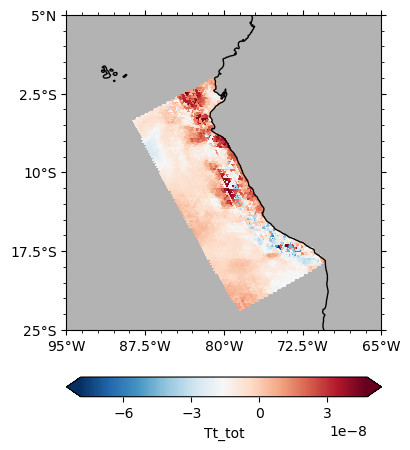

In [41]:
masked_ave = oce_bgt.isel(depth=0).where(mask_oce["pc_all"] == 1.0).mean(dim="time")
masked_ave.pyic.plot(
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    plot_method="tgrid",
    cmap="RdBu_r",
    land_facecolor="none",
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    # clim=[-1e-4, 1e-4],
)

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7ffb3fcbe3d0>])

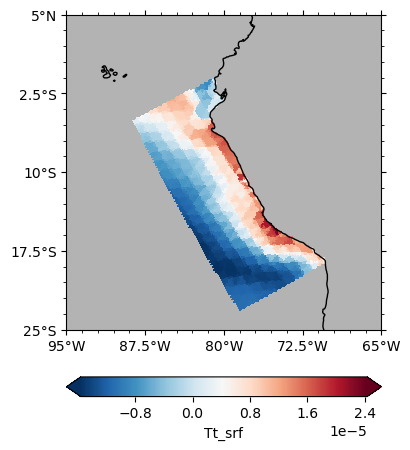

In [51]:
masked_ave = oce_bgt.isel(depth=0).where(mask_oce["pc_all"] == 1.0).mean(dim="time")
masked_ave.pyic.plot(
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    plot_method="tgrid",
    cmap="RdBu_r",
    land_facecolor="none",
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    # clim=[-1e-4, 1e-4],
)

In [49]:
print(oce_bgt.max())

<xarray.DataArray 'Tt_sur' ()> Size: 4B
array(0., dtype=float32)
